## Check class balance

### Wave

Training Set:
  Parkinson: 36 images
  Healthy: 36 images

Testing Set:
  Parkinson: 15 images
  Healthy: 15 images


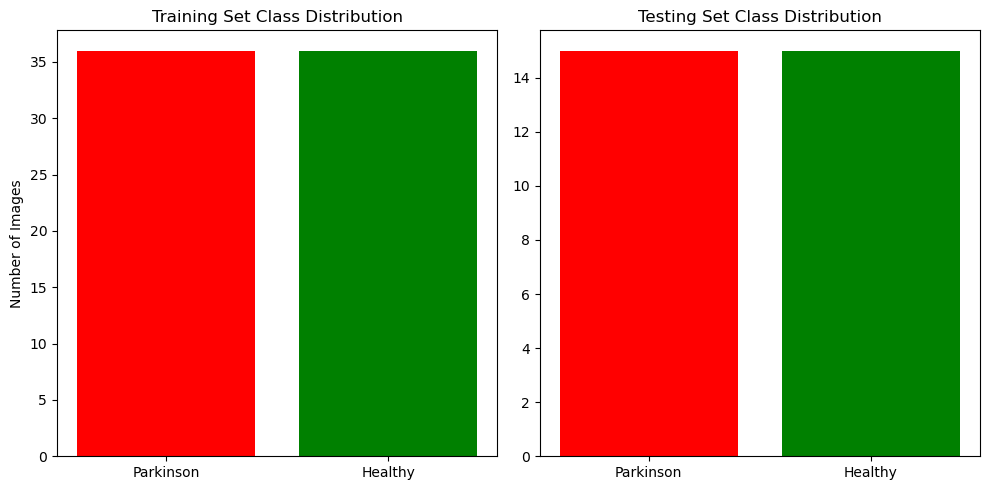

In [3]:
import os
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_path):
    # Define paths (FIXED)
    train_parkinson = os.path.join(dataset_path, "wave", "training", "parkinson")
    train_healthy = os.path.join(dataset_path, "wave", "training", "healthy")
    test_parkinson = os.path.join(dataset_path, "wave", "testing", "parkinson")
    test_healthy = os.path.join(dataset_path, "wave", "testing", "healthy")

    # Count files in each directory
    train_parkinson_count = len(os.listdir(train_parkinson))
    train_healthy_count = len(os.listdir(train_healthy))
    test_parkinson_count = len(os.listdir(test_parkinson))
    test_healthy_count = len(os.listdir(test_healthy))

    # Print counts
    print("Training Set:")
    print(f"  Parkinson: {train_parkinson_count} images")
    print(f"  Healthy: {train_healthy_count} images")
    print("\nTesting Set:")
    print(f"  Parkinson: {test_parkinson_count} images")
    print(f"  Healthy: {test_healthy_count} images")

    # Plot distribution
    plt.figure(figsize=(10, 5))
    
    # Training set
    plt.subplot(1, 2, 1)
    plt.bar(["Parkinson", "Healthy"], [train_parkinson_count, train_healthy_count], color=["red", "green"])
    plt.title("Training Set Class Distribution")
    plt.ylabel("Number of Images")
    
    # Testing set
    plt.subplot(1, 2, 2)
    plt.bar(["Parkinson", "Healthy"], [test_parkinson_count, test_healthy_count], color=["red", "green"])
    plt.title("Testing Set Class Distribution")
    
    plt.tight_layout()
    plt.show()

# Usage
dataset_path = "../dataset"  # Path to your dataset folder
plot_class_distribution(dataset_path)


### Spiral

Training Set:
  Parkinson: 36 images
  Healthy: 36 images

Testing Set:
  Parkinson: 15 images
  Healthy: 15 images


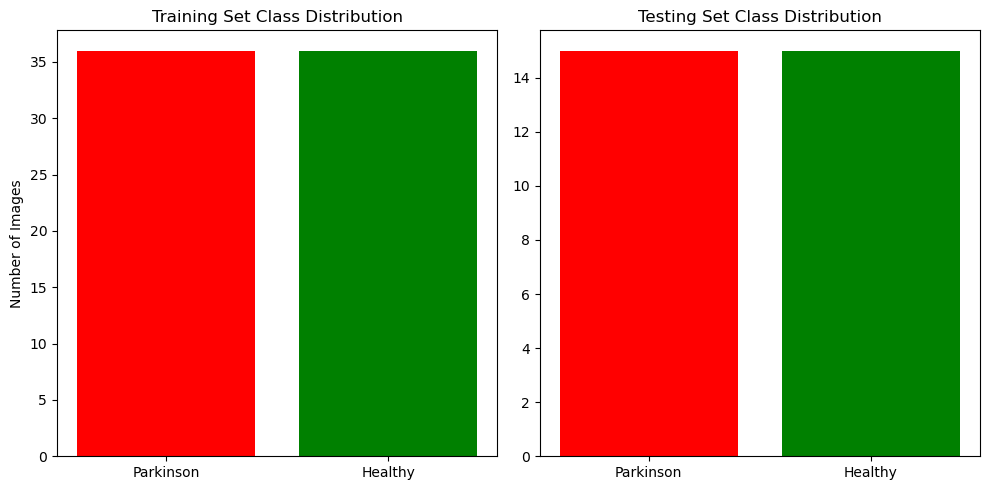

In [2]:
import os
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_path):
    # Define paths (FIXED)
    train_parkinson = os.path.join(dataset_path, "spiral", "training", "parkinson")
    train_healthy = os.path.join(dataset_path, "spiral", "training", "healthy")
    test_parkinson = os.path.join(dataset_path, "spiral", "testing", "parkinson")
    test_healthy = os.path.join(dataset_path, "spiral", "testing", "healthy")

    # Count files in each directory
    train_parkinson_count = len(os.listdir(train_parkinson))
    train_healthy_count = len(os.listdir(train_healthy))
    test_parkinson_count = len(os.listdir(test_parkinson))
    test_healthy_count = len(os.listdir(test_healthy))

    # Print counts
    print("Training Set:")
    print(f"  Parkinson: {train_parkinson_count} images")
    print(f"  Healthy: {train_healthy_count} images")
    print("\nTesting Set:")
    print(f"  Parkinson: {test_parkinson_count} images")
    print(f"  Healthy: {test_healthy_count} images")

    # Plot distribution
    plt.figure(figsize=(10, 5))
    
    # Training set
    plt.subplot(1, 2, 1)
    plt.bar(["Parkinson", "Healthy"], [train_parkinson_count, train_healthy_count], color=["red", "green"])
    plt.title("Training Set Class Distribution")
    plt.ylabel("Number of Images")
    
    # Testing set
    plt.subplot(1, 2, 2)
    plt.bar(["Parkinson", "Healthy"], [test_parkinson_count, test_healthy_count], color=["red", "green"])
    plt.title("Testing Set Class Distribution")
    
    plt.tight_layout()
    plt.show()

# Usage
dataset_path = "../dataset"  # Path to your dataset folder
plot_class_distribution(dataset_path)


## Resizing

### Wave

In [4]:
import os
import cv2

def create_resized_structure(dataset_path):
    # Define new directories
    resized_dirs = [
        os.path.join(dataset_path, "wave_resized/training/parkinson"),
        os.path.join(dataset_path, "wave_resized/training/healthy"),
        os.path.join(dataset_path, "wave_resized/testing/parkinson"),
        os.path.join(dataset_path, "wave_resized/testing/healthy")
    ]
    
    # Create directories if they don’t exist
    for dir_path in resized_dirs:
        os.makedirs(dir_path, exist_ok=True)
    
    return resized_dirs

In [5]:
def resize_with_padding(img, target_size=(224, 224)):
    # Get image dimensions
    h, w = img.shape[:2]
    
    # Calculate padding
    if h > w:
        # Portrait: pad width
        ratio = target_size[0] / h
        new_w = int(w * ratio)
        img = cv2.resize(img, (new_w, target_size[0]))
        pad_left = (target_size[1] - new_w) // 2
        pad_right = target_size[1] - new_w - pad_left
        img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
    else:
        # Landscape: pad height
        ratio = target_size[1] / w
        new_h = int(h * ratio)
        img = cv2.resize(img, (target_size[1], new_h))
        pad_top = (target_size[0] - new_h) // 2
        pad_bottom = target_size[0] - new_h - pad_top
        img = cv2.copyMakeBorder(img, pad_top, pad_bottom, 0, 0, cv2.BORDER_CONSTANT, value=0)
    
    return img

In [6]:
def process_images(dataset_path):
    # Create resized directory structure
    create_resized_structure(dataset_path)
    
    # Define original and resized paths
    splits = ["training", "testing"]
    classes = ["parkinson", "healthy"]
    
    for split in splits:
        for class_name in classes:
            # Paths
            orig_dir = os.path.join(dataset_path, f"wave/{split}/{class_name}")
            resized_dir = os.path.join(dataset_path, f"wave_resized/{split}/{class_name}")
            
            # Process each image
            for img_name in os.listdir(orig_dir):
                img_path = os.path.join(orig_dir, img_name)
                img = cv2.imread(img_path)
                
                # Resize with padding
                img_resized = resize_with_padding(img)
                
                # Save to new directory
                cv2.imwrite(os.path.join(resized_dir, img_name), img_resized)
    
    print("Resizing complete. Check the 'wave_resized' directory.")

In [7]:
dataset_path = "../dataset"  # Your dataset root path
process_images(dataset_path)

Resizing complete. Check the 'wave_resized' directory.


## Spiral

In [ ]:
import os
import cv2

def create_resized_structure(dataset_path):
    # Define new directories
    resized_dirs = [
        os.path.join(dataset_path, "spiral_resized/training/parkinson"),
        os.path.join(dataset_path, "spiral_resized/training/healthy"),
        os.path.join(dataset_path, "spiral_resized/testing/parkinson"),
        os.path.join(dataset_path, "spiral_resized/testing/healthy")
    ]
    
    # Create directories if they don’t exist
    for dir_path in resized_dirs:
        os.makedirs(dir_path, exist_ok=True)
    
    return resized_dirs

In [ ]:
def resize_with_padding(img, target_size=(224, 224)):
    # Get image dimensions
    h, w = img.shape[:2]
    
    # Calculate padding
    if h > w:
        # Portrait: pad width
        ratio = target_size[0] / h
        new_w = int(w * ratio)
        img = cv2.resize(img, (new_w, target_size[0]))
        pad_left = (target_size[1] - new_w) // 2
        pad_right = target_size[1] - new_w - pad_left
        img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
    else:
        # Landscape: pad height
        ratio = target_size[1] / w
        new_h = int(h * ratio)
        img = cv2.resize(img, (target_size[1], new_h))
        pad_top = (target_size[0] - new_h) // 2
        pad_bottom = target_size[0] - new_h - pad_top
        img = cv2.copyMakeBorder(img, pad_top, pad_bottom, 0, 0, cv2.BORDER_CONSTANT, value=0)
    
    return img

In [ ]:
def process_images(dataset_path):
    # Create resized directory structure
    create_resized_structure(dataset_path)
    
    # Define original and resized paths
    splits = ["training", "testing"]
    classes = ["parkinson", "healthy"]
    
    for split in splits:
        for class_name in classes:
            # Paths
            orig_dir = os.path.join(dataset_path, f"spiral/{split}/{class_name}")
            resized_dir = os.path.join(dataset_path, f"spiral_resized/{split}/{class_name}")
            
            # Process each image
            for img_name in os.listdir(orig_dir):
                img_path = os.path.join(orig_dir, img_name)
                img = cv2.imread(img_path)
                
                # Resize with padding
                img_resized = resize_with_padding(img)
                
                # Save to new directory
                cv2.imwrite(os.path.join(resized_dir, img_name), img_resized)
    
    print("Resizing complete. Check the 'spiral_resized' directory.")

In [ ]:
dataset_path = "../dataset"  # Your dataset root path
process_images(dataset_path)

## Data augmentation

In [8]:
import albumentations as A

augmentation_pipeline = A.Compose([
    # Geometric transforms
    A.Rotate(limit=10, p=0.5),                 # Small rotations (±10°)
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.5),  # Minor shifts
    A.ElasticTransform(alpha=1, sigma=20, alpha_affine=5, p=0.2),  # Simulate hand tremors (lightly)
    
    # Noise and quality
    A.GaussNoise(var_limit=(1, 5), p=0.3),     # ✅ FIXED: closed parentheses, added p
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    
    # Always resize to 224x224 (if not done earlier)
    A.Resize(224, 224)
])


### Wave

In [9]:
import cv2
import os
from tqdm import tqdm  # Progress bar

def augment_and_save_images(input_dir, output_dir, augmentations, num_augmented=3):
    """Augments each image in `input_dir` and saves `num_augmented` copies to `output_dir`."""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Albumentations uses RGB
        
        # Generate augmented versions
        for i in range(num_augmented):
            augmented = augmentations(image=img)["image"]
            augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)  # Convert back to BGR for saving
            cv2.imwrite(os.path.join(output_dir, f"{os.path.splitext(img_name)[0]}_aug_{i}.jpg"), augmented)

# Paths
dataset_path = "../dataset/wave_resized"  # Assuming images are already resized to 224x224
output_path = "../dataset/wave_augmented"

# Augment both classes
augment_and_save_images(
    input_dir=os.path.join(dataset_path, "training/parkinson"),
    output_dir=os.path.join(output_path, "training/parkinson"),
    augmentations=augmentation_pipeline,
    num_augmented=3  # 3 augmented copies per image
)

augment_and_save_images(
    input_dir=os.path.join(dataset_path, "training/healthy"),
    output_dir=os.path.join(output_path, "training/healthy"),
    augmentations=augmentation_pipeline,
    num_augmented=3
)

100%|██████████████████████████████████████████████████████████████████████████████████| 36/36 [00:01<00:00, 18.96it/s]


### Spiral

In [10]:
import cv2
import os
from tqdm import tqdm  # Progress bar

def augment_and_save_images(input_dir, output_dir, augmentations, num_augmented=3):
    """Augments each image in `input_dir` and saves `num_augmented` copies to `output_dir`."""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Albumentations uses RGB
        
        # Generate augmented versions
        for i in range(num_augmented):
            augmented = augmentations(image=img)["image"]
            augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)  # Convert back to BGR for saving
            cv2.imwrite(os.path.join(output_dir, f"{os.path.splitext(img_name)[0]}_aug_{i}.jpg"), augmented)

# Paths
dataset_path = "../dataset/spiral_resized"  # Assuming images are already resized to 224x224
output_path = "../dataset/spiral_augmented"

# Augment both classes
augment_and_save_images(
    input_dir=os.path.join(dataset_path, "training/parkinson"),
    output_dir=os.path.join(output_path, "training/parkinson"),
    augmentations=augmentation_pipeline,
    num_augmented=3  # 3 augmented copies per image
)

augment_and_save_images(
    input_dir=os.path.join(dataset_path, "training/healthy"),
    output_dir=os.path.join(output_path, "training/healthy"),
    augmentations=augmentation_pipeline,
    num_augmented=3
)

100%|██████████████████████████████████████████████████████████████████████████████████| 36/36 [00:01<00:00, 21.17it/s]


## Grayscale conversion

### Wave

In [11]:
import cv2
import os
from tqdm import tqdm

def convert_to_grayscale(input_dir, output_dir):
    """Converts all images in `input_dir` to grayscale and saves to `output_dir`."""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path)
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        cv2.imwrite(os.path.join(output_dir, img_name), gray_img)

# Paths
dataset_path = "../dataset"
augmented_train_path = os.path.join(dataset_path, "wave_augmented/training")  # Augmented training data
resized_test_path = os.path.join(dataset_path, "wave_resized/testing")       # Original testing data
output_path = os.path.join(dataset_path, "wave_grayscale")

# Convert TRAINING data (augmented)
for class_name in ["parkinson", "healthy"]:
    input_dir = os.path.join(augmented_train_path, class_name)
    output_dir = os.path.join(output_path, "training", class_name)
    convert_to_grayscale(input_dir, output_dir)

# Convert TESTING data (original, unaugmented)
for class_name in ["parkinson", "healthy"]:
    input_dir = os.path.join(resized_test_path, class_name)
    output_dir = os.path.join(output_path, "testing", class_name)
    convert_to_grayscale(input_dir, output_dir)

print("Grayscale conversion complete. Testing data remains unaugmented.")

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 55.76it/s]

Grayscale conversion complete. Testing data remains unaugmented.


### Spiral

In [12]:
import cv2
import os
from tqdm import tqdm

def convert_to_grayscale(input_dir, output_dir):
    """Converts all images in `input_dir` to grayscale and saves to `output_dir`."""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path)
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        cv2.imwrite(os.path.join(output_dir, img_name), gray_img)

# Paths
dataset_path = "../dataset"
augmented_train_path = os.path.join(dataset_path, "spiral_augmented/training")  # Augmented training data
resized_test_path = os.path.join(dataset_path, "spiral_resized/testing")       # Original testing data
output_path = os.path.join(dataset_path, "spiral_grayscale")

# Convert TRAINING data (augmented)
for class_name in ["parkinson", "healthy"]:
    input_dir = os.path.join(augmented_train_path, class_name)
    output_dir = os.path.join(output_path, "training", class_name)
    convert_to_grayscale(input_dir, output_dir)

# Convert TESTING data (original, unaugmented)
for class_name in ["parkinson", "healthy"]:
    input_dir = os.path.join(resized_test_path, class_name)
    output_dir = os.path.join(output_path, "testing", class_name)
    convert_to_grayscale(input_dir, output_dir)

print("Grayscale conversion complete. Testing data remains unaugmented.")

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 50.53it/s]

Grayscale conversion complete. Testing data remains unaugmented.


## Denoising

### Wave

In [13]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# Configuration
INPUT_DIR = "../dataset/wave_grayscale"  # Input grayscale images
OUTPUT_DIR = "../dataset/wave_denoised"  # Output directory for denoised images
DENOISE_STRENGTH = 7  # h parameter (typical range: 3-10, lower=less aggressive)

def denoise_image(img):
    """Apply non-local means denoising to a grayscale image."""
    return cv2.fastNlMeansDenoising(img, h=DENOISE_STRENGTH)

def process_directory(input_dir, output_dir):
    """Process all images in a directory and save denoised versions."""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        # Skip if image couldn't be loaded
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            continue
            
        denoised_img = denoise_image(img)
        cv2.imwrite(os.path.join(output_dir, img_name), denoised_img)

def main():
    # Process all splits (training/testing) and classes (healthy/parkinson)
    for split in ["training", "testing"]:
        for class_name in ["healthy", "parkinson"]:
            input_dir = os.path.join(INPUT_DIR, split, class_name)
            output_dir = os.path.join(OUTPUT_DIR, split, class_name)
            
            print(f"Processing: {split}/{class_name}")
            process_directory(input_dir, output_dir)
    
    print("\nDenoising complete! Results saved to:", OUTPUT_DIR)

if __name__ == "__main__":
    main()

Processing: training/healthy


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:18<00:00,  5.90it/s]


Processing: training/parkinson


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:15<00:00,  6.80it/s]


Processing: testing/healthy


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  6.80it/s]


Processing: testing/parkinson


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  6.70it/s]


Denoising complete! Results saved to: ../dataset/wave_denoised


### Spiral

In [14]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# Configuration
INPUT_DIR = "../dataset/spiral_grayscale"  # Input grayscale images
OUTPUT_DIR = "../dataset/spiral_denoised"  # Output directory for denoised images
DENOISE_STRENGTH = 7  # h parameter (typical range: 3-10, lower=less aggressive)

def denoise_image(img):
    """Apply non-local means denoising to a grayscale image."""
    return cv2.fastNlMeansDenoising(img, h=DENOISE_STRENGTH)

def process_directory(input_dir, output_dir):
    """Process all images in a directory and save denoised versions."""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        # Skip if image couldn't be loaded
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            continue
            
        denoised_img = denoise_image(img)
        cv2.imwrite(os.path.join(output_dir, img_name), denoised_img)

def main():
    # Process all splits (training/testing) and classes (healthy/parkinson)
    for split in ["training", "testing"]:
        for class_name in ["healthy", "parkinson"]:
            input_dir = os.path.join(INPUT_DIR, split, class_name)
            output_dir = os.path.join(OUTPUT_DIR, split, class_name)
            
            print(f"Processing: {split}/{class_name}")
            process_directory(input_dir, output_dir)
    
    print("\nDenoising complete! Results saved to:", OUTPUT_DIR)

if __name__ == "__main__":
    main()

Processing: training/healthy


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:17<00:00,  6.11it/s]


Processing: training/parkinson


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:17<00:00,  6.04it/s]


Processing: testing/healthy


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  6.42it/s]


Processing: testing/parkinson


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  6.01it/s]


Denoising complete! Results saved to: ../dataset/spiral_denoised


## Edge enhancement

### Wave

In [15]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# Configuration
INPUT_DIR = "../dataset/wave_denoised"  # Input denoised images
OUTPUT_DIR = "../dataset/wave_edge_enhanced"  # Output directory
ENHANCEMENT_METHOD = "unsharp"  # Options: "sobel" or "unsharp"

def enhance_edges_sobel(img):
    """Edge enhancement using Sobel operator"""
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    edge_enhanced = cv2.magnitude(sobel_x, sobel_y)
    return cv2.normalize(edge_enhanced, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

def enhance_edges_unsharp(img):
    """Edge enhancement using unsharp masking"""
    blurred = cv2.GaussianBlur(img, (5, 5), 2.0)
    return cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

def process_directory(input_dir, output_dir):
    """Process all images in a directory and save enhanced versions"""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            continue
            
        if ENHANCEMENT_METHOD == "sobel":
            enhanced_img = enhance_edges_sobel(img)
        else:
            enhanced_img = enhance_edges_unsharp(img)
            
        cv2.imwrite(os.path.join(output_dir, img_name), enhanced_img)

def main():
    # Process all splits and classes
    for split in ["training", "testing"]:
        for class_name in ["healthy", "parkinson"]:
            input_dir = os.path.join(INPUT_DIR, split, class_name)
            output_dir = os.path.join(OUTPUT_DIR, split, class_name)
            
            print(f"Processing: {split}/{class_name} ({ENHANCEMENT_METHOD} method)")
            process_directory(input_dir, output_dir)
    
    print("\nEdge enhancement complete! Results saved to:", OUTPUT_DIR)

if __name__ == "__main__":
    main()

Processing: training/healthy (unsharp method)


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:01<00:00, 86.92it/s]


Processing: training/parkinson (unsharp method)


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:01<00:00, 80.67it/s]


Processing: testing/healthy (unsharp method)


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 70.97it/s]


Processing: testing/parkinson (unsharp method)


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 80.38it/s]


Edge enhancement complete! Results saved to: ../dataset/wave_edge_enhanced


### Spiral

In [16]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# Configuration
INPUT_DIR = "../dataset/spiral_denoised"  # Input denoised images
OUTPUT_DIR = "../dataset/spiral_edge_enhanced"  # Output directory
ENHANCEMENT_METHOD = "unsharp"  # Options: "sobel" or "unsharp"

def enhance_edges_sobel(img):
    """Edge enhancement using Sobel operator"""
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    edge_enhanced = cv2.magnitude(sobel_x, sobel_y)
    return cv2.normalize(edge_enhanced, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

def enhance_edges_unsharp(img):
    """Edge enhancement using unsharp masking"""
    blurred = cv2.GaussianBlur(img, (5, 5), 2.0)
    return cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

def process_directory(input_dir, output_dir):
    """Process all images in a directory and save enhanced versions"""
    os.makedirs(output_dir, exist_ok=True)
    for img_name in tqdm(os.listdir(input_dir)):
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            continue
            
        if ENHANCEMENT_METHOD == "sobel":
            enhanced_img = enhance_edges_sobel(img)
        else:
            enhanced_img = enhance_edges_unsharp(img)
            
        cv2.imwrite(os.path.join(output_dir, img_name), enhanced_img)

def main():
    # Process all splits and classes
    for split in ["training", "testing"]:
        for class_name in ["healthy", "parkinson"]:
            input_dir = os.path.join(INPUT_DIR, split, class_name)
            output_dir = os.path.join(OUTPUT_DIR, split, class_name)
            
            print(f"Processing: {split}/{class_name} ({ENHANCEMENT_METHOD} method)")
            process_directory(input_dir, output_dir)
    
    print("\nEdge enhancement complete! Results saved to:", OUTPUT_DIR)

if __name__ == "__main__":
    main()

Processing: training/healthy (unsharp method)


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:01<00:00, 68.28it/s]


Processing: training/parkinson (unsharp method)


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [00:01<00:00, 62.46it/s]


Processing: testing/healthy (unsharp method)


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 54.24it/s]


Processing: testing/parkinson (unsharp method)


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 51.10it/s]


Edge enhancement complete! Results saved to: ../dataset/spiral_edge_enhanced


## Normalization

### Wave

In [17]:
import torch
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

# Configuration
INPUT_DIR = "../dataset/wave_edge_enhanced"  # Your edge-enhanced images
OUTPUT_DIR = "../dataset/wave_normalized"   # Output directory
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ImageNet normalization stats (adapted for grayscale)
MEAN = [0.485, 0.456, 0.406]  # Standard ImageNet mean
STD = [0.229, 0.224, 0.225]    # Standard ImageNet std

# Define transforms
normalize = transforms.Compose([
    transforms.Resize(256),                      # Slightly larger than 224 for center crop
    transforms.CenterCrop(224),                  # ResNet18 input size
    transforms.Grayscale(num_output_channels=3), # Convert to 3-channel "RGB"
    transforms.ToTensor(),                       # [0,255] -> [0,1]
    transforms.Normalize(mean=MEAN, std=STD)     # ImageNet normalization
])

def normalize_and_save():
    """Process all images, normalize, and save with same structure."""
    for split in ["training", "testing"]:
        for class_name in ["healthy", "parkinson"]:
            input_dir = os.path.join(INPUT_DIR, split, class_name)
            output_dir = os.path.join(OUTPUT_DIR, split, class_name)
            os.makedirs(output_dir, exist_ok=True)
            
            img_files = [f for f in os.listdir(input_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for img_name in tqdm(img_files, desc=f"Normalizing {split}/{class_name}"):
                # Load and normalize image
                img_path = os.path.join(input_dir, img_name)
                img = Image.open(img_path).convert('L')  # Ensure grayscale
                normalized = normalize(img)
                
                # Convert back to PIL image for saving
                # First denormalize and scale to [0,255]
                denormalized = torch.clamp(
                    normalized * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1),
                    0, 1
                )
                denormalized = denormalized * 255.0
                denormalized = denormalized.byte().permute(1, 2, 0).cpu().numpy()
                
                # Save
                output_path = os.path.join(output_dir, img_name)
                Image.fromarray(denormalized).save(output_path)

if __name__ == "__main__":
    normalize_and_save()
    print(f"Normalized images saved to {OUTPUT_DIR}")

Normalizing testing/parkinson: 100%|███████████████████████████████████████████████████| 15/15 [00:00<00:00, 23.04it/s]

Normalized images saved to ../dataset/wave_normalized


### Spiral

In [18]:
import torch
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

# Configuration
INPUT_DIR = "../dataset/spiral_edge_enhanced"  # Your edge-enhanced images
OUTPUT_DIR = "../dataset/spiral_normalized"   # Output directory
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ImageNet normalization stats (adapted for grayscale)
MEAN = [0.485, 0.456, 0.406]  # Standard ImageNet mean
STD = [0.229, 0.224, 0.225]    # Standard ImageNet std

# Define transforms
normalize = transforms.Compose([
    transforms.Resize(256),                      # Slightly larger than 224 for center crop
    transforms.CenterCrop(224),                  # ResNet18 input size
    transforms.Grayscale(num_output_channels=3), # Convert to 3-channel "RGB"
    transforms.ToTensor(),                       # [0,255] -> [0,1]
    transforms.Normalize(mean=MEAN, std=STD)     # ImageNet normalization
])

def normalize_and_save():
    """Process all images, normalize, and save with same structure."""
    for split in ["training", "testing"]:
        for class_name in ["healthy", "parkinson"]:
            input_dir = os.path.join(INPUT_DIR, split, class_name)
            output_dir = os.path.join(OUTPUT_DIR, split, class_name)
            os.makedirs(output_dir, exist_ok=True)
            
            img_files = [f for f in os.listdir(input_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for img_name in tqdm(img_files, desc=f"Normalizing {split}/{class_name}"):
                # Load and normalize image
                img_path = os.path.join(input_dir, img_name)
                img = Image.open(img_path).convert('L')  # Ensure grayscale
                normalized = normalize(img)
                
                # Convert back to PIL image for saving
                # First denormalize and scale to [0,255]
                denormalized = torch.clamp(
                    normalized * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1),
                    0, 1
                )
                denormalized = denormalized * 255.0
                denormalized = denormalized.byte().permute(1, 2, 0).cpu().numpy()
                
                # Save
                output_path = os.path.join(output_dir, img_name)
                Image.fromarray(denormalized).save(output_path)

if __name__ == "__main__":
    normalize_and_save()
    print(f"Normalized images saved to {OUTPUT_DIR}")

Normalizing testing/parkinson: 100%|███████████████████████████████████████████████████| 15/15 [00:00<00:00, 29.58it/s]

Normalized images saved to ../dataset/spiral_normalized
